<a href="https://colab.research.google.com/github/sophia-yang424/aca_chemprop/blob/main/my_pipeline_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 2. Clone the repo or download it
!git clone https://github.com/chemprop/chemprop_benchmark_v2.git
%cd chemprop_benchmark_v2

# 3. Clean up any corrupted files, then download and extract the data properly
!rm -rf data.tar.gz data/
!wget https://zenodo.org/records/10078142/files/data.tar.gz
!tar -xzvf data.tar.gz

Cloning into 'chemprop_benchmark_v2'...
remote: Enumerating objects: 698, done.
remote: Counting objects: 100% (238/238), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 698 (delta 161), reused 95 (delta 57), pack-reused 460 (from 1)
Receiving objects: 100% (698/698), 441.81 KiB | 11.04 MiB/s, done.
Resolving deltas: 100% (498/498), done.
/content/chemprop_benchmark_v2
--2026-09-18 20:27:10--  https://zenodo.org/records/10078142/files/data.tar.gz
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1632346035 (1.5G) [application/octet-stream]
Saving to: ‘data.tar.gz’

data.tar.gz         100%[===================>]   1.52G  12.8MB/s    in 6m 57s  

2026-09-18 20:34:08 (3.73 MB/s) - ‘data.tar.gz’ saved [1632346035/1632346035]

data/
data/barriers_sn2/
data/barriers_sn2/test.csv
data/barriers_sn2/val.csv
da

In [7]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.metrics import r2_score
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from chemprop import data, featurizers, models, nn as cp_nn
from chemprop.data.splitting import make_split_indices, split_data_by_indices

import warnings
warnings.filterwarnings('ignore')

In [6]:
%pip install -q chembl_webresource_client rdkit chemprop optuna tqdm lightning scikit-learn seaborn optuna-integration[pytorch_lightning]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.3/154.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd

# Load the split data directly from the CSV files
train_df = pd.read_csv('data/barriers_sn2/train.csv')
val_df = pd.read_csv('data/barriers_sn2/val.csv')
test_df = pd.read_csv('data/barriers_sn2/test.csv')

print(f"Test: {len(test_df)}, Train: {len(train_df)}, Val: {len(val_df)}")
# Expected Output: Test: 4113, Train: 32901, Val: 4113 (based on typical dataset sizes)

In [ ]:

import sys
from rdkit import RDLogger

# Suppress RDKit warnings
lg = RDLogger.logger()
lg.setLevel(RDLogger.ERROR)

for key in list(sys.modules.keys()):
    if key.startswith('torchvision'):
        del sys.modules[key]


# 1. Build datapoints directly from the explicitly loaded DataFrames
def build_reaction_datapoints(df, smiles_col='AAM', label_col='ea'):
    smis = df[smiles_col].tolist()
    ys = df[[label_col]].values
    # Use ReactionDatapoint since these are reaction SMILES with '>>'
    return [data.ReactionDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]

print("Building datasets from explicit splits...")
train_data = build_reaction_datapoints(train_df)
val_data = build_reaction_datapoints(val_df)
test_data = build_reaction_datapoints(test_df)

# 2. Build Datasets & scale targets
# Use the default featurizer for ReactionDataset to properly handle reaction tuples
train_dset = data.ReactionDataset(train_data)
val_dset = data.ReactionDataset(val_data)
test_dset = data.ReactionDataset(test_data)

target_scaler = train_dset.normalize_targets()
val_dset.normalize_targets(target_scaler)
test_dset.normalize_targets(target_scaler)

# 3. Build Dataloaders
train_loader = data.build_dataloader(train_dset, num_workers=0, shuffle=True)
val_loader = data.build_dataloader(val_dset, num_workers=0, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=0, shuffle=False)
train_loader_eval = data.build_dataloader(train_dset, num_workers=0, shuffle=False)

pl.seed_everything(42, workers=True)

# Dynamically extract feature dimensions from the dataloader for Reaction graphs
sample_batch = next(iter(train_loader))
# Handle both .v/.e and .V/.E attribute naming conventions just in case
d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]
print(f"Extracted feature dimensions: d_v={d_v}, d_e={d_e}")

# 4. Define Model with extracted hyperparameters (max_lr = 0.001)
hidden_size = 300
output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

# Pass the dynamically extracted dimensions into the message passing block
mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size)
agg = cp_nn.NormAggregation()
ffn = cp_nn.RegressionFFN(
    input_dim=hidden_size,
    output_transform=output_transform,
    dropout=0.15,
)
mpnn = models.MPNN(
    mp, agg, ffn,
    batch_norm=True,
    metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
    warmup_epochs=2,
    init_lr=1e-4,
    max_lr=0.001,
    final_lr=1e-4,
) #hyperparamters i got from the chemprop run itself when it searched

# 5. Train
early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices=1,
    enable_progress_bar=True,
    callbacks=[early_stop, checkpoint],
)

print("\nTraining custom pipeline on explicit splits...")
trainer.fit(mpnn, train_loader, val_loader)

# 6. Evaluate
best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
mpnn.load_state_dict(best_ckpt['state_dict'])
mpnn.eval()

def get_r2(loader, true_data):
    preds = trainer.predict(mpnn, loader)
    y_pred = torch.cat(preds).numpy().flatten()
    y_true = np.array([d.y[0] for d in true_data])
    return r2_score(y_true, y_pred)

r2_test = get_r2(test_loader, test_data)
r2_train = get_r2(train_loader_eval, train_data)

print(f"\n=== Custom Pipeline Final Results (barriers_sn2) ===")
print(f"Train R^2: {r2_train:.4f}")
print(f"Test R^2:  {r2_test:.4f}")


on molecule ace benchmark

In [8]:
!pip install -q chemprop lightning
!pip install -q chembl_webresource_client python-Levenshtein torch-geometric
!pip install -q --no-deps MoleculeACE

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.0 MB/s eta 0:00:00


In [9]:
!pip install rdkit-pypi pandas numpy pandas chembl_webresource_client scikit-learn matplotlib tqdm python-Levenshtein

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


getting baseline for molecule ace benchmark data from moleculeAce paper using our chemprop gnn training pipeline BEFORE loss function modifcations. we used a custom pytorch training pipeline instead of chemprops built in trainer because the latter wouldnt let you touch the loss function used which we will chnage later:
below you will see a training cell that trains both for mixed aca and isolated aca (2 function callss of training fucniton we define)

In [10]:
from chemprop.data.splitting import make_split_indices, split_data_by_indices
from chemprop import data as cp_data
from rdkit import Chem

def scaffold_train_val_test_split(smiles_list, y_list, sizes=(0.7, 0.15, 0.15), seed=42):
    """Scaffold-aware three-way split, replacing sklearn's train_test_split."""
    dps = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_list, y_list)]

    train_idx, val_idx, test_idx = make_split_indices(
        mols=[d.mol for d in dps],
        split="scaffold_balanced",
        sizes=sizes,
        seed=seed,
    )
    train_data, val_data, test_data = split_data_by_indices(dps, train_idx, val_idx, test_idx)
    if isinstance(train_data[0], list):
        train_data, val_data, test_data = train_data[0], val_data[0], test_data[0]

    def unpack(data_list):
        smis = [d.smi if hasattr(d, 'smi') else Chem.MolToSmiles(d.mol) for d in data_list]
        ys = [d.y[0] for d in data_list]
        return smis, ys

    smiles_tr, y_tr = unpack(train_data)
    smiles_val, y_val = unpack(val_data)
    smiles_te, y_te = unpack(test_data)

    return smiles_tr, smiles_val, smiles_te, y_tr, y_val, y_te


def scaffold_train_val_split(smiles_list, y_list, val_size=0.15, seed=42):
    """Two-way wrapper around the three-way splitter, for carving a val set
    out of an already-separately-provided training set (test discarded)."""
    smiles_tr, smiles_val, _te, y_tr, y_val, _y_te = scaffold_train_val_test_split(
        smiles_list, y_list, sizes=(1 - val_size, val_size, 0.0), seed=seed
    )
    return smiles_tr, smiles_val, y_tr, y_val

In [11]:
from MoleculeACE import Data, datasets
import pandas as pd

# View all available datasets
print(datasets)  # 30 datasets from the benchmark study

# Load any dataset (e.g., CHEMBL2034_Ki - Glucocorticoid receptor)
data = Data('CHEMBL2034_Ki')

# Access the data
smiles_train = data.smiles_train
y_train = data.y_train

smiles_test = data.smiles_test
y_test = data.y_test

# Save to CSV if needed
train_df = pd.DataFrame({'smiles': smiles_train, 'y': y_train})
test_df = pd.DataFrame({'smiles': smiles_test, 'y': y_test})
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

['CHEMBL4203_Ki', 'CHEMBL2034_Ki', 'CHEMBL233_Ki', 'CHEMBL4616_EC50', 'CHEMBL287_Ki', 'CHEMBL218_EC50', 'CHEMBL264_Ki', 'CHEMBL219_Ki', 'CHEMBL2835_Ki', 'CHEMBL2147_Ki', 'CHEMBL231_Ki', 'CHEMBL3979_EC50', 'CHEMBL237_EC50', 'CHEMBL244_Ki', 'CHEMBL4792_Ki', 'CHEMBL1871_Ki', 'CHEMBL237_Ki', 'CHEMBL262_Ki', 'CHEMBL2047_EC50', 'CHEMBL239_EC50', 'CHEMBL2971_Ki', 'CHEMBL204_Ki', 'CHEMBL214_Ki', 'CHEMBL1862_Ki', 'CHEMBL234_Ki', 'CHEMBL238_Ki', 'CHEMBL235_EC50', 'CHEMBL4005_Ki', 'CHEMBL236_Ki', 'CHEMBL228_Ki']


In [12]:
from MoleculeACE import Data

data = Data('CHEMBL2034_Ki')

# Get only activity cliff compounds
cliff_indices = [i for i, cliff in enumerate(data.cliff_mols_test) if cliff == 1]
cliff_smiles = [data.smiles_test[i] for i in cliff_indices]
cliff_y = [data.y_test[i] for i in cliff_indices]

print(f"Total test: {len(data.smiles_test)}")
print(f"Cliff test: {len(cliff_smiles)}")

Total test: 152
Cliff test: 52


In [13]:
!git clone https://github.com/molML/MoleculeACE.git

Cloning into 'MoleculeACE'...
remote: Enumerating objects: 2181, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 2181 (delta 38), reused 34 (delta 34), pack-reused 2136 (from 2)
Receiving objects: 100% (2181/2181), 24.26 MiB | 55.69 MiB/s, done.
Resolving deltas: 100% (898/898), done.


In [14]:
from sklearn.model_selection import train_test_split
from MoleculeACE import Data
import numpy as np

mac_data = Data('CHEMBL2034_Ki')

# --- 1. FULL DATA SPLITS ---
smiles_train_full = mac_data.smiles_train
y_train_full = mac_data.y_train
smiles_test_full = mac_data.smiles_test
y_test_full = mac_data.y_test

# Split train into train and val (85/15)
smiles_tr_full, smiles_val_full, y_tr_full, y_val_full = scaffold_train_val_split(
    smiles_train_full, y_train_full, val_size=0.15, seed=42
)

# --- 2. ACTIVITY CLIFF ONLY SPLITS ---
# Get indices of cliff compounds
cliff_tr_idx = [i for i, c in enumerate(mac_data.cliff_mols_train) if c == 1]
cliff_te_idx = [i for i, c in enumerate(mac_data.cliff_mols_test) if c == 1]

smiles_cliff_train = [mac_data.smiles_train[i] for i in cliff_tr_idx]
y_cliff_train = [mac_data.y_train[i] for i in cliff_tr_idx]
smiles_cliff_test = [mac_data.smiles_test[i] for i in cliff_te_idx]
y_cliff_test = [mac_data.y_test[i] for i in cliff_te_idx]

# Split cliff train into train and val (85/15)
smiles_tr_cliff, smiles_val_cliff, y_tr_cliff, y_val_cliff = scaffold_train_val_split(
    smiles_cliff_train, y_cliff_train, val_size=0.15, seed=42
)

print(f"Full Data - Train: {len(smiles_tr_full)}, Val: {len(smiles_val_full)}, Test: {len(smiles_test_full)}")
print(f"Cliff Data - Train: {len(smiles_tr_cliff)}, Val: {len(smiles_val_cliff)}, Test: {len(smiles_cliff_test)}")

Full Data - Train: 509, Val: 89, Test: 152
Cliff Data - Train: 170, Val: 29, Test: 52


In [30]:
import torch.optim as optim
from chemprop.models.model import build_NoamLike_LRSched# or wherever this is defined in your install

class MPNNWithWeightDecay(models.MPNN):
    def __init__(self, *args, weight_decay=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._weight_decay = weight_decay

    def configure_optimizers(self):
        opt = optim.Adam(self.parameters(), self.init_lr, weight_decay=self._weight_decay)

        if self.trainer.train_dataloader is None:
            self.trainer.estimated_stepping_batches

        steps_per_epoch = self.trainer.num_training_batches
        warmup_steps = self.warmup_epochs * steps_per_epoch
        if self.trainer.max_epochs == -1:
            cooldown_steps = 100 * warmup_steps
        else:
            cooldown_epochs = self.trainer.max_epochs - self.warmup_epochs
            cooldown_steps = cooldown_epochs * steps_per_epoch

        lr_sched = build_NoamLike_LRSched(
            opt, warmup_steps, cooldown_steps, self.init_lr, self.max_lr, self.final_lr
        )
        lr_sched_config = {"scheduler": lr_sched, "interval": "step"}

        return {"optimizer": opt, "lr_scheduler": lr_sched_config}

In [92]:
#setting datapoints up (getting the one hot features from the smile strings for input + settingup training function)
from chemprop import data as cp_data, models, nn as cp_nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import torch
from sklearn.metrics import r2_score

def train_chemprop_model(smiles_tr, y_tr, smiles_val, y_val, smiles_te, y_te, model_name):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Build datapoints (MoleculeDatapoint since these are single molecules, not reactions)
    train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
    val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]
    test_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_te, y_te)]

    train_dset = cp_data.MoleculeDataset(train_pts)
    val_dset = cp_data.MoleculeDataset(val_pts)
    test_dset = cp_data.MoleculeDataset(test_pts)

    target_scaler = train_dset.normalize_targets()
    val_dset.normalize_targets(target_scaler)
    test_dset.normalize_targets(target_scaler)

    train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
    val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)
    test_loader = cp_data.build_dataloader(test_dset, num_workers=0, shuffle=False)

    pl.seed_everything(42, workers=True)

    # Extract dimensions
    sample_batch = next(iter(train_loader))
    d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
    d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

    # Define Model
    hidden_size = 300
    output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

    mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size)
    agg = cp_nn.NormAggregation()
    #agg = cp_nn.MeanAggregation()
    ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=0.15)

    mpnn = models.MPNN(
        mp, agg, ffn, batch_norm=True,
        metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
        warmup_epochs=2, init_lr=1e-4, max_lr=0.001, final_lr=1e-4,
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
    checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

    trainer = pl.Trainer(
        max_epochs=100, accelerator="auto", devices=1,
        enable_progress_bar=True, callbacks=[early_stop, checkpoint],
    )

    trainer.fit(mpnn, train_loader, val_loader)

    # Evaluate
    best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
    mpnn.load_state_dict(best_ckpt['state_dict'])
    mpnn.eval()

    preds = trainer.predict(mpnn, test_loader)
    y_pred = torch.cat(preds).numpy().flatten()
    r2_test = r2_score(y_te, y_pred)

    print(f"\n>>> {model_name} Final Test R^2: {r2_test:.4f} <<<")
    return mpnn, trainer, test_loader

In [ ]:
# Train on FULL MoleculeACE dataset
mpnn_full, trainer_full, test_loader_full = train_chemprop_model(
    smiles_tr_full, y_tr_full,
    smiles_val_full, y_val_full,
    smiles_test_full, y_test_full,
    "Model 1: Full CHEMBL2034_Ki Data"
)

In [ ]:
# Train on ACTIVITY CLIFF compounds ONLY
mpnn_cliff, trainer_cliff, test_loader_cliff = train_chemprop_model(
    smiles_tr_cliff, y_tr_cliff,
    smiles_val_cliff, y_val_cliff,
    smiles_cliff_test, y_cliff_test,
    "Model 2: Activity Cliff Compounds Only"
)

In [28]:
import inspect
print(inspect.getsource(models.MPNN.configure_optimizers))
help(models.MPNN.__init__)  # look again carefully for anything optimizer-related

    def configure_optimizers(self):
        opt = optim.Adam(self.parameters(), self.init_lr)
        if self.trainer.train_dataloader is None:
            # Loading `train_dataloader` to estimate number of training batches.
            # Using this line of code can pypass the issue of using `num_training_batches` as described [here](https://github.com/Lightning-AI/pytorch-lightning/issues/16060).
            self.trainer.estimated_stepping_batches
        steps_per_epoch = self.trainer.num_training_batches
        warmup_steps = self.warmup_epochs * steps_per_epoch
        if self.trainer.max_epochs == -1:
            logger.warning(
                "For infinite training, the number of cooldown epochs in learning rate scheduler is set to 100 times the number of warmup epochs."
            )
            cooldown_steps = 100 * warmup_steps
        else:
            cooldown_epochs = self.trainer.max_epochs - self.warmup_epochs
            cooldown_steps = cooldown_epochs * steps_per_ep

In [ ]:
!pip install optuna

In [93]:
import optuna
import lightning.pytorch as pl
from chemprop import data as cp_data, models, nn as cp_nn
from lightning.pytorch.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

def optimize_hyperparams_full(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=100):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        hidden_size = trial.suggest_int("hidden_size", 200, 300)
        depth = 4  # fixed - unanimous across every top-5 result so far

        dropout = trial.suggest_float("dropout", 0.15, 0.42)
        weight_decay = trial.suggest_float("weight_decay", 0.005, 0.03, log=True)

        init_lr = trial.suggest_float("init_lr", 3e-5, 2e-4, log=True)
        max_lr = trial.suggest_float("max_lr", init_lr, init_lr * 10, log=True)
       # hidden_size = trial.suggest_int("hidden_size", 140, 230)
       # depth = trial.suggest_int("depth",4, 4)
        #dropout = trial.suggest_float("dropout", 0.0, 0.45)
        #init_lr = trial.suggest_float("init_lr", 5e-5, 5e-4, log=True)
        #max_lr = trial.suggest_float("max_lr", 3e-5, 3e-4, log=True)
        #weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 5e-4, 5e-2, log=True)

        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.NormAggregation()
        #agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = MPNNWithWeightDecay(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
            weight_decay=weight_decay
        )

        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)

        # Extract training loss and save it to the trial attributes
        metrics = trainer.callback_metrics
        t_loss = metrics.get("train_loss") or metrics.get("train/loss")
        if t_loss is not None:
            trial.set_user_attr("train_loss", t_loss.item() if hasattr(t_loss, 'item') else float(t_loss))

        return metrics["val_loss"].item()

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study, study.best_params

study_full, best_params_full = optimize_hyperparams_full(
    smiles_tr_full, y_tr_full, smiles_val_full, y_val_full,
    study_name="Full CHEMBL2034_Ki Data", n_trials=100
)


[I 2026-09-18 23:46:05,311] A new study created in memory with name: no-name-dd00ff06-b2b0-4134-8ca7-a8a64afb8ae0
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/)


Starting Optuna Hyperparameter Search for: Full CHEMBL2034_Ki Data


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  127 K │ train │     0 │
│ 1 │ agg             │ NormAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    432 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 65.4 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 193 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 193 K                                                                                                
Total estimated model params size (MB): 0.774                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[I 2026-09-18 23:46:10,163] Trial 0 finished with value: 0.765755295753479 and parameters: {'hidden_size': 216, 'dropout': 0.3649396314074357, 'weight_decay': 0.029039442952809632, 'init_lr': 3.781606375920145e-05, 'max_lr': 0.000255313240305915}. Best is trial 0 with value: 0.765755295753479.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and a

...

[I 2026-09-18 23:53:19,262] Trial 98 finished with value: 0.6659755706787109 and parameters: {'hidden_size': 243, 'dropout': 0.23502934144495796, 'weight_decay': 0.02712840120531883, 'init_lr': 0.00017755114036297569, 'max_lr': 0.0008068959767449368}. Best is trial 84 with value: 0.5048334002494812.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  159 K │ train │     0 │
│ 1 │ agg             │ NormAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    490 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 74.1 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 233 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 233 K                                                                                                
Total estimated model params size (MB): 0.934                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[I 2026-09-18 23:53:22,840] Trial 99 finished with value: 0.6718683242797852 and parameters: {'hidden_size': 245, 'dropout': 0.2496347042342606, 'weight_decay': 0.022854766988751423, 'init_lr': 0.00015952089593364898, 'max_lr': 0.0007582097714403444}. Best is trial 84 with value: 0.5048334002494812.



=== Best Hyperparameters for Full CHEMBL2034_Ki Data ===
{'hidden_size': 258, 'dropout': 0.22555059317379023, 'weight_decay': 0.023331290055857542, 'init_lr': 0.0001655089689318985, 'max_lr': 0.0005916614183632717}
Best Val Loss: 0.5048334002494812



### Visualizations for Full Data Hyperparameter Study

In [78]:
import optuna.visualization as vis

# Plot parameter importances for Full Data
fig_full_importance = vis.plot_param_importances(study_full)
fig_full_importance.update_layout(title_text='Parameter Importance for Full Data')
fig_full_importance.show()

In [36]:
# Plot optimization history for Full Data
fig_full_history = vis.plot_optimization_history(study_full)
fig_full_history.update_layout(title_text='Optimization History for Full Data')
fig_full_history.show()

In [37]:
# Plot parallel coordinate for Full Data
fig_full_parallel = vis.plot_parallel_coordinate(study_full)
fig_full_parallel.update_layout(title_text='Parallel Coordinate Plot for Full Data')
fig_full_parallel.show()

#### Slice Plots: Distribution of Loss for Individual Hyperparameters (Full Data)

In [38]:
# Plot slice for each hyperparameter for Full Data

hyperparameters_full = ['hidden_size', 'depth', 'dropout', 'init_lr', 'max_lr']

for param in hyperparameters_full:
    fig_full_slice = vis.plot_slice(study_full, params=[param])
    fig_full_slice.update_layout(title_text=f'Slice Plot of {param} for Full Data')
    fig_full_slice.show()

#### Contour Plots: Relationship Between Pairs of Hyperparameters and Loss (Full Data)

In [39]:
# Plot contour for pairs of hyperparameters for Full Data

pairs_full = [
    ('hidden_size', 'depth'),
    ('dropout', 'max_lr'),
    ('init_lr', 'max_lr')
]

for x_param, y_param in pairs_full:
    fig_full_contour = vis.plot_contour(study_full, params=[x_param, y_param])
    fig_full_contour.update_layout(title_text=f'Contour Plot of {x_param} vs {y_param} for Full Data')
    fig_full_contour.show()

[W 2026-09-18 21:14:27,139] Param depth unique value length is less than 2.


In [ ]:
# HYPERPARAMETER SEARCH 2: ISOLATED (ONLY AC MOLECULE DATA)

def optimize_hyperparams_cliff(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=100):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        hidden_size = trial.suggest_int("hidden_size", 50, 300)
        depth = trial.suggest_int("depth", 2, 3)
        dropout = trial.suggest_float("dropout", 0.3, 0.85)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", init_lr, init_lr * 10, log=True)
       # max_lr = trial.suggest_float("max_lr", 1e-5, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.NormAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = MPNNWithWeightDecay(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
            weight_decay=weight_decay
        )

        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)

        # Extract training loss and save it to the trial attributes
        metrics = trainer.callback_metrics
        t_loss = metrics.get("train_loss") or metrics.get("train/loss")
        if t_loss is not None:
            trial.set_user_attr("train_loss", t_loss.item() if hasattr(t_loss, 'item') else float(t_loss))

        return metrics["val_loss"].item()

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study, study.best_params

study_cliff, best_params_cliff = optimize_hyperparams_cliff(
    smiles_tr_cliff, y_tr_cliff, smiles_val_cliff, y_val_cliff,
    study_name="Activity Cliff Compounds Only", n_trials=100
)


### Visualizations for Activity Cliff Only Data Hyperparameter Study

In [ ]:
import optuna.visualization as vis

# Plot parameter importances for Activity Cliff Only Data
fig_cliff_importance = vis.plot_param_importances(study_cliff)
fig_cliff_importance.update_layout(title_text='Parameter Importance for Activity Cliff Only Data')
fig_cliff_importance.show()

In [ ]:
# Plot optimization history for Activity Cliff Only Data
fig_cliff_history = vis.plot_optimization_history(study_cliff)
fig_cliff_history.update_layout(title_text='Optimization History for Activity Cliff Only Data')
fig_cliff_history.show()

In [ ]:
# Plot parallel coordinate for Activity Cliff Only Data
fig_cliff_parallel = vis.plot_parallel_coordinate(study_cliff)
fig_cliff_parallel.update_layout(title_text='Parallel Coordinate Plot for Activity Cliff Only Data')
fig_cliff_parallel.show()

#### Slice Plots: Distribution of Loss for Individual Hyperparameters (Activity Cliff Only Data)

In [ ]:
# Plot slice for each hyperparameter for Activity Cliff Only Data

hyperparameters_cliff = ['hidden_size', 'depth', 'dropout', 'init_lr', 'max_lr']

for param in hyperparameters_cliff:
    fig_cliff_slice = vis.plot_slice(study_cliff, params=[param])
    fig_cliff_slice.update_layout(title_text=f'Slice Plot of {param} for Activity Cliff Only Data')
    fig_cliff_slice.show()

#### Contour Plots: Relationship Between Pairs of Hyperparameters and Loss (Activity Cliff Only Data)

In [ ]:
# Plot contour for pairs of hyperparameters for Activity Cliff Only Data

pairs_cliff = [
    ('hidden_size', 'depth'),
    ('dropout', 'max_lr'),
    ('init_lr', 'max_lr')
]

for x_param, y_param in pairs_cliff:
    fig_cliff_contour = vis.plot_contour(study_cliff, params=[x_param, y_param])
    fig_cliff_contour.update_layout(title_text=f'Contour Plot of {x_param} vs {y_param} for Activity Cliff Only Data')
    fig_cliff_contour.show()

In [ ]:
#viz for most important hyperprameters since thi skeeps underfitting
import optuna.visualization as vis

# To use the visualization, we need the study object itself.
# Let's recreate the study locally or re-run a quick version if the study object isn't directly available in memory.
# Wait, I notice we only returned `study.best_params` from our functions.
# Let's write a quick modified search or just note that we need the `study` object to plot it.
# Since we didn't save the `study` object, let's re-run a fast search on non-cliff data and return the study to plot it.

def get_study_and_plot(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=20):
    print(f"\n{'='*50}\nRunning short search to get feature importance for: {study_name}\n{'='*50}")

    def objective(trial):
        hidden_size = trial.suggest_int("hidden_size", 100, 400)
        depth = trial.suggest_int("depth", 3, 5)
        dropout = trial.suggest_float("dropout", 0.05, 0.25)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", init_lr, init_lr * 10, log=True)
#        max_lr = trial.suggest_float("max_lr", 1e-5, 5e-3, log=True)

        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        #agg = cp_nn.MeanAggregation()
        agg = cp_nn.NormAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = models.MPNN(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
        )

        early_stop = EarlyStopping(monitor="val_loss", patience=3, mode="min")
        trainer = pl.Trainer(
            max_epochs=15, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)
        return trainer.callback_metrics["val_loss"].item()

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # Plot parameter importances
    fig = vis.plot_param_importances(study)
    fig.show()

    return study

# Run a short study to get the importance plot
study_non_cliff = get_study_and_plot(
    smiles_tr_cliff, y_tr_cliff, smiles_val_cliff, y_val_cliff,
    study_name="Importance Study Full"
)


In [87]:
from chemprop import data as cp_data, models, nn as cp_nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

def train_tuned_chemprop_model(smiles_tr, y_tr, smiles_val, y_val, smiles_te, y_te, model_name, best_params, seed=42):
    print(f"\n{'='*50}\nTraining {model_name} (Seed: {seed})\n{'='*50}")

    # 1. Build datapoints and datasets
    train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
    val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]
    test_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_te, y_te)]

    train_dset = cp_data.MoleculeDataset(train_pts)
    val_dset = cp_data.MoleculeDataset(val_pts)
    test_dset = cp_data.MoleculeDataset(test_pts)

    target_scaler = train_dset.normalize_targets()
    val_dset.normalize_targets(target_scaler)
    test_dset.normalize_targets(target_scaler)

    train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
    val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)
    test_loader = cp_data.build_dataloader(test_dset, num_workers=0, shuffle=False)

    pl.seed_everything(seed, workers=True)

    # 2. Extract dimensions
    sample_batch = next(iter(train_loader))
    d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
    d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

    # 3. Define Model using OPTUNA best parameters
    output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

    mp = cp_nn.BondMessagePassing(
        d_v=d_v, d_e=d_e,
        d_h=best_params["hidden_size"],
        depth=best_params["depth"]
    )
    #agg = cp_nn.MeanAggregation()
    agg = cp_nn.NormAggregation()  # Changed to NormAggregation based on request
    ffn = cp_nn.RegressionFFN(
        input_dim=best_params["hidden_size"],
        output_transform=output_transform,
        dropout=best_params["dropout"]
    )

    mpnn = MPNNWithWeightDecay(
        mp, agg, ffn, batch_norm=True,
        metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
        warmup_epochs=2,
        init_lr=best_params["init_lr"],
        max_lr=best_params["max_lr"],
        final_lr=best_params["init_lr"],
        weight_decay=best_params.get("weight_decay", 0.0)
    )

    # 4. Train - Relaxed early stopping criteria
    early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min", min_delta=0.001)
    checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

    # Use CSVLogger to track train and val losses per epoch
    logger = CSVLogger("logs", name=f"{model_name.replace(' ', '_').replace(':', '')}_seed_{seed}")

    trainer = pl.Trainer(
        max_epochs=100, accelerator="auto", devices=1,
        enable_progress_bar=False,
        logger=logger,
        callbacks=[early_stop, checkpoint],
        deterministic=True  # Force deterministic GPU operations
    )

    trainer.fit(mpnn, train_loader, val_loader)

    # 5. Evaluate best model
    best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
    mpnn.load_state_dict(best_ckpt['state_dict'])
    mpnn.eval()

    best_epoch = best_ckpt.get('epoch', 'Unknown')
    best_val_loss = checkpoint.best_model_score.item() if checkpoint.best_model_score is not None else float('nan')
    print(f"\n[INFO] Loaded Best Model Checkpoint from Epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")

    preds = trainer.predict(mpnn, test_loader)
    y_pred = torch.cat(preds).numpy().flatten()

    r2_test = r2_score(y_te, y_pred)
    mse_test = mean_squared_error(y_te, y_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_te, y_pred)

    print(f"\n>>> {model_name} (Seed {seed}) Final Test Results <<<")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Test R^2:      {r2_test:.4f}")
    print(f"Test MSE:      {mse_test:.4f}")
    print(f"Test RMSE:     {rmse_test:.4f}")
    print(f"Test MAE:      {mae_test:.4f}")

    metrics_dict = {
        "val_loss_best": best_val_loss,
        "r2": r2_test,
        "mse": mse_test,
        "rmse": rmse_test,
        "mae": mae_test
    }

    metrics_file = f"{logger.save_dir}/{logger.name}/version_{logger.version}/metrics.csv"

    # 6. Plot Learning Curve Automatically
    try:
        df = pd.read_csv(metrics_file)
        df_agg = df.groupby("epoch").mean().reset_index()

        plt.figure(figsize=(8, 5))

        train_cols = [c for c in df_agg.columns if 'train' in c.lower() and 'loss' in c.lower()]
        val_cols = [c for c in df_agg.columns if 'val' in c.lower() and 'loss' in c.lower()]

        if train_cols:
            plt.plot(df_agg["epoch"], df_agg[train_cols[0]], label="Train Loss", marker="o", markersize=4)

        if val_cols:
            plt.plot(df_agg["epoch"], df_agg[val_cols[0]], label="Val Loss", marker="s", markersize=4)

        plt.title(f"Learning Curve: {model_name} (Seed {seed})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot curves: {e}")

    return mpnn, trainer, test_loader, metrics_dict, metrics_file


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload


Using Hyperparameters: {'hidden_size': 258, 'dropout': 0.22555059317379023, 'weight_decay': 0.023331290055857542, 'init_lr': 0.0001655089689318985, 'max_lr': 0.0005916614183632717, 'depth': 4}
Using Aggregation: NormAggregation

Training tuned models across multiple seeds...

Training Tuned Model: Full CHEMBL2034_Ki Data (Seed: 42)


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  174 K │ train │     0 │
│ 1 │ agg             │ NormAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    516 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 78.0 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 252 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 252 K                                                                                                
Total estimated model params size (MB): 1.011                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 37 (Val Loss: 0.4926)

>>> Tuned Model: Full CHEMBL2034_Ki Data (Seed 42) Final Test Results <<<
Best Val Loss: 0.4926
Test R^2:      0.3700
Test MSE:      0.6357
Test RMSE:     0.7973
Test MAE:      0.5728


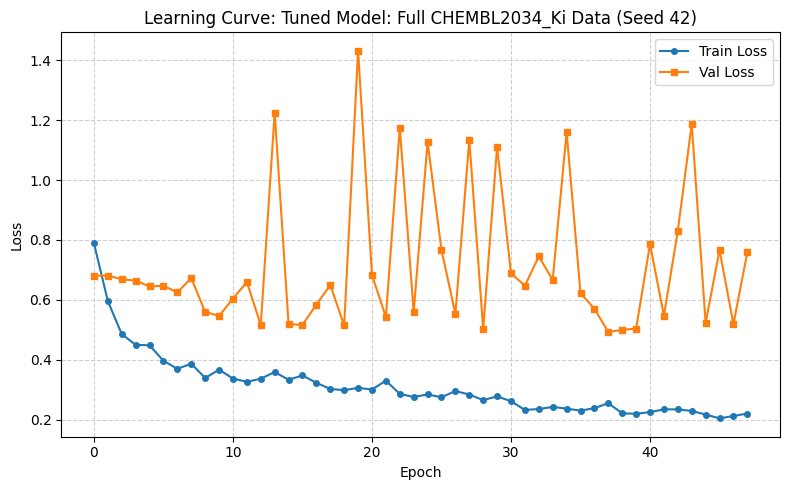

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Seed set to 123
INFO:lightning.fabric.utilities.seed:Seed set to 123
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_

Seed 42 -> Train R^2: 0.7593 | Test R^2: 0.3700 | Gap: 0.3893


Training Tuned Model: Full CHEMBL2034_Ki Data (Seed: 123)


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  174 K │ train │     0 │
│ 1 │ agg             │ NormAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    516 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 78.0 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 252 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 252 K                                                                                                
Total estimated model params size (MB): 1.011                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 13 (Val Loss: 0.5116)

>>> Tuned Model: Full CHEMBL2034_Ki Data (Seed 123) Final Test Results <<<
Best Val Loss: 0.5116
Test R^2:      0.3215
Test MSE:      0.6846
Test RMSE:     0.8274
Test MAE:      0.6519


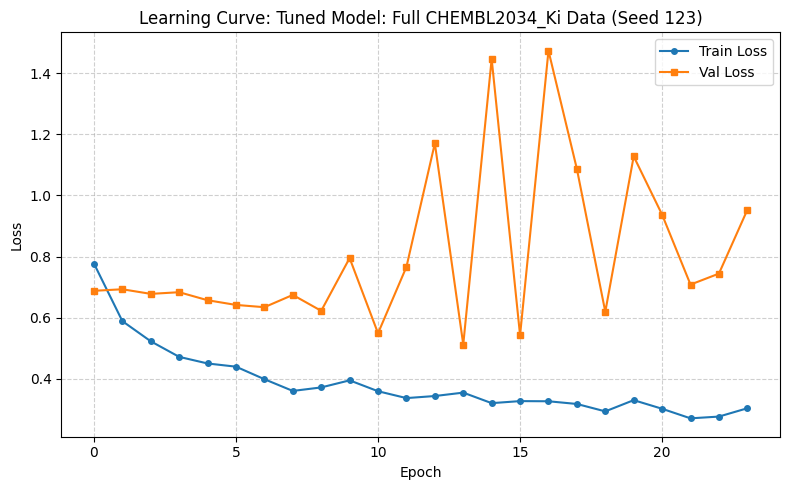

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Seed set to 456
INFO:lightning.fabric.utilities.seed:Seed set to 456
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_

Seed 123 -> Train R^2: 0.5346 | Test R^2: 0.3215 | Gap: 0.2132


Training Tuned Model: Full CHEMBL2034_Ki Data (Seed: 456)


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  174 K │ train │     0 │
│ 1 │ agg             │ NormAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    516 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 78.0 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 252 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 252 K                                                                                                
Total estimated model params size (MB): 1.011                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 34 (Val Loss: 0.4873)

>>> Tuned Model: Full CHEMBL2034_Ki Data (Seed 456) Final Test Results <<<
Best Val Loss: 0.4873
Test R^2:      0.3856
Test MSE:      0.6199
Test RMSE:     0.7873
Test MAE:      0.5745


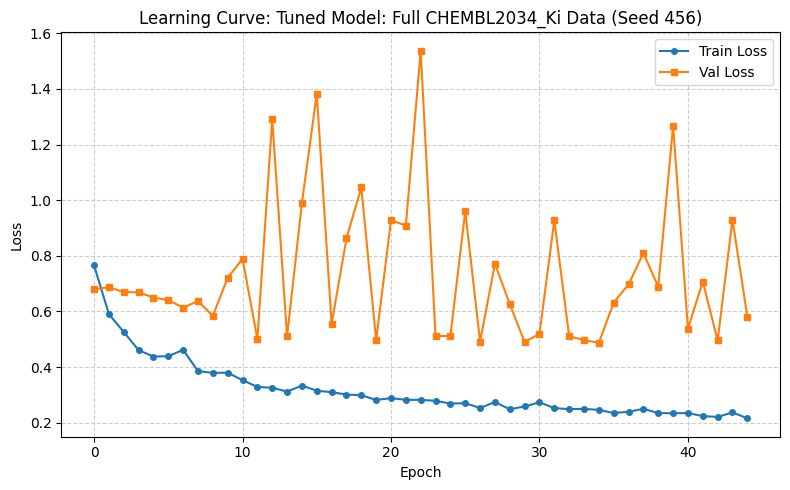

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Seed 456 -> Train R^2: 0.7372 | Test R^2: 0.3856 | Gap: 0.3516


=== Multi-Seed Results (Full Data) ===
Seeds tested: [42, 123, 456]
Test R^2 scores: ['0.3700', '0.3215', '0.3856']
Mean Test R^2: 0.3590 ± 0.0273


In [95]:
# --- Train Tuned Baselines Multi-Seed ---
import numpy as np

# Ensure 'depth' is in best_params_full since it was fixed during Optuna search
if "depth" not in best_params_full:
    best_params_full["depth"] = 4

print(f"\n{'='*50}")
print(f"Using Hyperparameters: {best_params_full}")
print(f"Using Aggregation: NormAggregation")
print(f"{'='*50}\n")

seeds = [42, 123, 456]
test_r2_scores = []

print("Training tuned models across multiple seeds...")
for s in seeds:
    mpnn_full_tuned, trainer_full_tuned, test_loader_full_tuned, metrics_dict_full, metrics_full = train_tuned_chemprop_model(
        smiles_tr_full, y_tr_full, smiles_val_full, y_val_full, smiles_test_full, y_test_full,
        "Tuned Model: Full CHEMBL2034_Ki Data", best_params_full, seed=s
    )
    test_r2_scores.append(metrics_dict_full['r2'])

    # Calculate Train R^2 for current seed
    train_pts_full = [cp_data.MoleculeDatapoint.from_smi(s_mi, [y]) for s_mi, y in zip(smiles_tr_full, y_tr_full)]
    train_dset_full = cp_data.MoleculeDataset(train_pts_full)
    train_loader_full_eval = cp_data.build_dataloader(train_dset_full, num_workers=0, shuffle=False)

    preds = trainer_full_tuned.predict(mpnn_full_tuned, train_loader_full_eval)
    y_pred_train_full = torch.cat(preds).numpy().flatten()
    r2_train_full = r2_score(y_tr_full, y_pred_train_full)

    print(f"Seed {s} -> Train R^2: {r2_train_full:.4f} | Test R^2: {metrics_dict_full['r2']:.4f} | Gap: {r2_train_full - metrics_dict_full['r2']:.4f}\n")

mean_r2 = np.mean(test_r2_scores)
std_r2 = np.std(test_r2_scores)

print(f"\n{'='*50}")
print(f"=== Multi-Seed Results (Full Data) ===")
print(f"{'='*50}")
print(f"Seeds tested: {seeds}")
print(f"Test R^2 scores: {[f'{score:.4f}' for score in test_r2_scores]}")
print(f"Mean Test R^2: {mean_r2:.4f} ± {std_r2:.4f}")

In [ ]:
#train model w ideal params for isolated
_, _, _, metrics_dict_cliff, metrics_cliff = train_tuned_chemprop_model(
    smiles_tr_cliff, y_tr_cliff, smiles_val_cliff, y_val_cliff, smiles_cliff_test, y_cliff_test,
    "Tuned Model: Activity Cliff Compounds Only", best_params_cliff
)
print(f"Train R^2: {r2_train_full:.4f}")
print(f"Test R^2:  {metrics_dict_full['r2']:.4f}")
print(f"Gap:       {r2_train_full - metrics_dict_full['r2']:.4f}")


In [ ]:
#plots of learning curves for final parameters we used ot teian ours (not optuna)
# plots of the models for AFTER optuna right, like the ones after we used the selected set of optimal params
import pandas as pd
import matplotlib.pyplot as plt

def plot_learning_curves(metrics_csv, title):
    try:
        df = pd.read_csv(metrics_csv)
        # Group by epoch to handle staggered train/val logging steps
        df_agg = df.groupby("epoch").mean().reset_index()

        plt.figure(figsize=(8, 5))

        # Dynamically find the train and val loss column names
        train_cols = [c for c in df_agg.columns if 'train' in c.lower() and 'loss' in c.lower()]
        val_cols = [c for c in df_agg.columns if 'val' in c.lower() and 'loss' in c.lower()]

        if train_cols:
            # Drop NaNs just in case logging steps don't perfectly align
            t_data = df_agg[['epoch', train_cols[0]]].dropna()
            plt.plot(t_data["epoch"], t_data[train_cols[0]], label="Train Loss", marker="o", markersize=4)

        if val_cols:
            v_data = df_agg[['epoch', val_cols[0]]].dropna()
            plt.plot(v_data["epoch"], v_data[val_cols[0]], label="Val Loss", marker="s", markersize=4)

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not plot {title}: {e}")

print("--- Overfitting Check: Best Hyperparameters ---")
plot_learning_curves(metrics_full, "Learning Curves: Full Mixed Data (Best Params)")
plot_learning_curves(metrics_cliff, "Learning Curves: Isolated Activity Cliffs (Best Params)")

### 3. Non-Activity Cliff (Normal) Compounds
Let's isolate the 'normal' compounds to see how well the model handles a smooth SAR landscape compared to the sharp activity cliffs. Above we evalauted chemprop on 1. the mixed data ac and non ac and 2. only ac data. lets look at third case (only non ac)

In [ ]:
# --- 1. NON-ACTIVITY CLIFF SPLITS ---
# Get indices of non-cliff compounds (where cliff == 0)
non_cliff_tr_idx = [i for i, c in enumerate(mac_data.cliff_mols_train) if c == 0]
non_cliff_te_idx = [i for i, c in enumerate(mac_data.cliff_mols_test) if c == 0]

smiles_non_cliff_train = [mac_data.smiles_train[i] for i in non_cliff_tr_idx]
y_non_cliff_train = [mac_data.y_train[i] for i in non_cliff_tr_idx]
smiles_non_cliff_test = [mac_data.smiles_test[i] for i in non_cliff_te_idx]
y_non_cliff_test = [mac_data.y_test[i] for i in non_cliff_te_idx]

# Split non-cliff train into train and val (85/15)
smiles_tr_non_cliff, smiles_val_non_cliff, y_tr_non_cliff, y_val_non_cliff = scaffold_train_val_split(
    smiles_non_cliff_train, y_non_cliff_train, val_size=0.15, seed=42
)

print(f"Non-Cliff Data - Train: {len(smiles_tr_non_cliff)}, Val: {len(smiles_val_non_cliff)}, Test: {len(smiles_non_cliff_test)}")

In [41]:
import optuna
import lightning.pytorch as pl
from chemprop import data as cp_data, models, nn as cp_nn
from lightning.pytorch.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

def optimize_hyperparams_non_cliff(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=50):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        hidden_size = trial.suggest_int("hidden_size", 100, 400)
        depth = trial.suggest_int("depth", 3, 5)
        dropout = trial.suggest_float("dropout", 0.05, 0.25)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", init_lr, init_lr * 10, log=True)
       # max_lr = trial.suggest_float("max_lr", 1e-5, 5e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.NormAggregation()
       # agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = MPNNWithWeightDecay(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
            weight_decay=weight_decay
        )

        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)

        # Extract training loss and save it to the trial attributes
        metrics = trainer.callback_metrics
        t_loss = metrics.get("train_loss") or metrics.get("train/loss")
        if t_loss is not None:
            trial.set_user_attr("train_loss", t_loss.item() if hasattr(t_loss, 'item') else float(t_loss))

        return metrics["val_loss"].item()

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study, study.best_params

study_non_cliff, best_params_non_cliff = optimize_hyperparams_non_cliff(
    smiles_tr_non_cliff, y_tr_non_cliff,
    smiles_val_non_cliff, y_val_non_cliff,
    study_name="Non-Activity Cliff Compounds",
    n_trials=100
)


NameError: name 'smiles_tr_non_cliff' is not defined

### Visualizations for Non-Activity Cliff Hyperparameter Study

In [ ]:
import optuna.visualization as vis

# Plot parameter importances for Non-Activity Cliff data
fig_non_cliff_importance = vis.plot_param_importances(study_non_cliff)
fig_non_cliff_importance.update_layout(title_text='Parameter Importance for Non-Activity Cliff Data')
fig_non_cliff_importance.show()

In [ ]:
# Plot optimization history for Non-Activity Cliff data
fig_non_cliff_history = vis.plot_optimization_history(study_non_cliff)
fig_non_cliff_history.update_layout(title_text='Optimization History for Non-Activity Cliff Data')
fig_non_cliff_history.show()

In [ ]:
# Plot parallel coordinate for Non-Activity Cliff data
fig_non_cliff_parallel = vis.plot_parallel_coordinate(study_non_cliff)
fig_non_cliff_parallel.update_layout(title_text='Parallel Coordinate Plot for Non-Activity Cliff Data')
fig_non_cliff_parallel.show()

#### Slice Plots: Distribution of Loss for Individual Hyperparameters

In [ ]:
# Plot slice for each hyperparameter for Non-Activity Cliff data

hyperparameters_non_cliff = ['hidden_size', 'depth', 'dropout', 'init_lr', 'max_lr']

for param in hyperparameters_non_cliff:
    fig_non_cliff_slice = vis.plot_slice(study_non_cliff, params=[param])
    fig_non_cliff_slice.update_layout(title_text=f'Slice Plot of {param} for Non-Activity Cliff Data')
    fig_non_cliff_slice.show()

#### Contour Plots: Relationship Between Pairs of Hyperparameters and Loss

In [ ]:
# Plot contour for pairs of hyperparameters for Non-Activity Cliff data

# Example pairs, adjust as needed based on importance or interest
pairs_non_cliff = [
    ('hidden_size', 'depth'),
    ('dropout', 'max_lr'),
    ('init_lr', 'max_lr')
]

for x_param, y_param in pairs_non_cliff:
    fig_non_cliff_contour = vis.plot_contour(study_non_cliff, params=[x_param, y_param])
    fig_non_cliff_contour.update_layout(title_text=f'Contour Plot of {x_param} vs {y_param} for Non-Activity Cliff Data')
    fig_non_cliff_contour.show()

In [ ]:
# --- 3. TRAIN TUNED MODEL ON NON-CLIFF DATA ---
_, _, _, metrics_dict_non_cliff, metrics_non_cliff = train_tuned_chemprop_model(
    smiles_tr_non_cliff, y_tr_non_cliff,
    smiles_val_non_cliff, y_val_non_cliff,
    smiles_non_cliff_test, y_non_cliff_test,
    "Tuned Model: Non-Activity Cliff Compounds",
    best_params_non_cliff
)

In [ ]:
# --- 4. PLOT LEARNING CURVES ---
print("--- Overfitting Check: Non-Activity Cliffs ---")
plot_learning_curves(metrics_non_cliff, "Learning Curves: Non-Activity Cliffs (Best Params)")

### View Top 5 Trials (Best Hyperparameters and Losses)


Top 5 Trials for Full Data


,number,value,params_dropout,params_hidden_size,params_init_lr,params_max_lr,params_weight_decay,user_attrs_train_loss
84,84,0.504833,0.225551,258,0.000166,0.000592,0.023331,0.291229
88,88,0.537646,0.199730,235,0.000181,0.000606,0.016331,0.292831
31,31,0.545562,0.243129,237,0.000164,0.000653,0.021552,0.270387
73,73,0.549402,0.204637,241,0.000196,0.000535,0.017275,0.297536
60,60,0.552900,0.242317,248,0.000197,0.000910,0.023838,0.271432


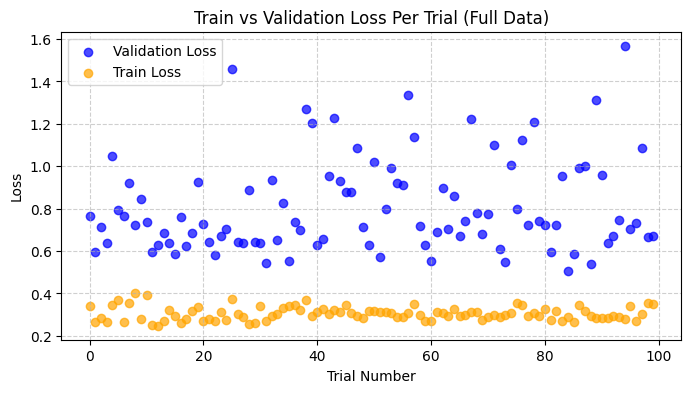

In [94]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

studies = {}
if 'study_full' in globals():
    studies["Full Data"] = study_full
if 'study_cliff' in globals():
    studies["Activity Cliff Only"] = study_cliff
if 'study_non_cliff' in globals():
    studies["Non-Activity Cliff"] = study_non_cliff

if not studies:
    print("No completed studies found in memory. Please run the hyperparameter search cells first.")
else:
    for name, study in studies.items():
        print(f"\n{'='*40}\nTop 5 Trials for {name}\n{'='*40}")
        try:
            df = study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs', 'state'))
            df_complete = df[df['state'] == 'COMPLETE'].copy()

            if df_complete.empty:
                continue

            df_top5 = df_complete.sort_values(by='value', ascending=True).head(5)
            display(df_top5.drop(columns=['state']))

            # If we successfully recorded train_loss, plot it alongside val_loss
            if 'user_attrs_train_loss' in df_complete.columns:
                plt.figure(figsize=(8, 4))
                plt.scatter(df_complete['number'], df_complete['value'], label='Validation Loss', alpha=0.7, color='blue')
                plt.scatter(df_complete['number'], df_complete['user_attrs_train_loss'], label='Train Loss', alpha=0.7, color='orange')
                plt.title(f"Train vs Validation Loss Per Trial ({name})")
                plt.xlabel("Trial Number")
                plt.ylabel("Loss")
                plt.legend()
                plt.grid(True, linestyle="--", alpha=0.6)
                plt.show()
            else:
                print(f"Note: Training loss was not recorded in {name}. Re-run the updated search cells to see the comparison plot.")

        except Exception as e:
            print(f"Could not display trials for {name}: {e}")

In [81]:
help(cp_nn.RegressionFFN.__init__)

Help on function __init__ in module chemprop.nn.predictors:

__init__(
    self,
    n_tasks: int = 1,
    input_dim: int = 300,
    hidden_dim: Union[int, Sequence[int]] = 300,
    n_layers: int = 1,
    dropout: float = 0.0,
    activation: str | torch.nn.modules.module.Module = 'relu',
    criterion: chemprop.nn.metrics.ChempropMetric | None = None,
    task_weights: torch.Tensor | None = None,
    threshold: float | None = None,
    output_transform: chemprop.nn.transforms.UnscaleTransform | None = None
)
    Initialize internal Module state, shared by both nn.Module and ScriptModule.



In [56]:
print(study_full.trials_dataframe()[['params_init_lr', 'params_max_lr']].apply(lambda row: row['params_max_lr'] < row['params_init_lr'], axis=1).sum())

92
